In [1]:
import numpy as np
from collections import namedtuple
import networkx as nx
import matplotlib.pyplot as plt
from jinja2.compiler import generate
from networkx.classes import edges
from sympy.physics.units import voltage

potential_params = namedtuple('params', ['s', 't', 'E'])

In [2]:
def rd_graph_from_file_nx(path):
    
    G = nx.Graph()
    
    with open(path, "r") as file:
        s, t, E = map(int, file.readline().split())
        for line in file:
            p, q, w = map(int, line.split())
            G.add_edge(p, q, R=w)
        
    return G, potential_params(s, t , E)

In [3]:
def find_potentials_nx(graph: nx.Graph, params: potential_params):
    s, t, E = params.s, params.t, params.E
    n = len(graph)+1
    
    G = np.zeros((n, n))
    J = np.zeros(n)
    J[n-1] = E
    
    for p, q, w in graph.edges(data='R'):
        #Na przekątnej konduktywność jest dodatnia a poza przekątną ujemna
        cond = 1.0 / w
        G[p, p] += cond
        G[q, q] += cond
        G[p, q] -= cond
        G[q, p] -= cond
    
    #Dodajemy na obrzerzach 1 i -1, dla naszego źródła i ujścia prądu
    G[s, n-1] += 1
    G[t, n-1] -= 1
    G[n-1, s] += 1
    G[n-1, t] -= 1
    
    ref_node = t
    G[ref_node, :] = 0        
    G[ref_node, ref_node] = 1 
    J[ref_node] = 0
    
    V = np.linalg.solve(G, J)
    
    return V

In [15]:
def find_potentials_kirchhoff(graph: nx.Graph, params):
    s, t, E = params.s, params.t, params.E
    
    nodes = list(graph.nodes())
    edges = list(graph.edges(data=True))
    m = len(edges)
    n = len(nodes)
    
    edge_to_idx = {tuple(sorted((u, v))): i for i, (u, v, d) in enumerate(edges)}

    M = np.zeros((m, m))
    B = np.zeros(m)
    row = 0

    #Wypełnimay pierwszy wiersz macierzy z pierwszego prawa Kirkhoffa. Dla prądów wchodzących wstawiamy 1 dla wychodzących -1
    for node in nodes:
        if node == t: continue
        if row >= n - 1: break
        
        for u, v, data in graph.edges(node, data=True):
            e_idx = edge_to_idx[tuple(sorted((u, v)))]
            direction = 1 if u == node else -1
            M[row, e_idx] = direction
        row += 1

    #MST
    spanning_tree = nx.minimum_spanning_tree(graph)
    tree_edges = set([tuple(sorted((u, v))) for u, v in spanning_tree.edges()])
    
    chords = [e for e in edge_to_idx.keys() if e not in tree_edges]
    
    #Wyznaczamy m cykli oraz ścieżki pomiędzy wierzchołkami pomiędzy którymi isteje cięciwa
    for u, v in chords:
        if row >= m: break
        path = nx.shortest_path(spanning_tree, source=u, target=v)
        
        c_idx = edge_to_idx[tuple(sorted((u, v)))]
        r_c = graph[u][v]['R']
        M[row, c_idx] = r_c
        
        for i in range(len(path) - 1):
            u_prim, v_prim = path[i], path[i+1]
            e_idx = edge_to_idx[tuple(sorted((u_prim, v_prim)))]
            r = graph[u_prim][v_prim]['R']
            M[row, e_idx] = -r if (u_prim, v_prim) in graph.edges else r
            
        row += 1

    #Dopisujemy przepływ pomiędzy s->t
    if row < m:
        path = nx.shortest_path(graph, s, t)
        for i in range(len(path) - 1):
            u, v = path[i], path[i+1]
            e_idx = edge_to_idx[tuple(sorted((u, v)))]
            r = graph[u][v]['R']
            M[row, e_idx] = r
        B[row] = E

    try:
        I_currents = np.linalg.solve(M, B) #Próba rozwiązania dla dobrego układu
    except np.linalg.LinAlgError:
        I_currents = np.linalg.lstsq(M, B, rcond=None)[0] #Rozwiązanie dla układu nadokreślonego. 

    potentials = {node: 0.0 for node in nodes}
    visited = {t}
    stack = [t]
    
    #Przechdozimy DFS po grafie i wyliczamy odpowiednie wartości potencjałów w węzłach.    
    while stack:
        u = stack.pop()
        for v in graph.neighbors(u):
            if v not in visited:
                e_idx = edge_to_idx[tuple(sorted((u, v)))]
                
                r = graph[u][v]['R']
                u_orig, v_orig = tuple(sorted((u, v)))
                
                #Dokonaliśmy założenia, że prąd płynie z wierzchołka o mniejszym id do takiego z większym id. Nasz kod automatycznie naprawi znaki jeśli w rzeczywistości będzie odwrotonie
                actual_I = I_currents[e_idx] if u == v_orig else -I_currents[e_idx]
                potentials[v] = potentials[u] + (actual_I * r)
                
                visited.add(v)
                stack.append(v)

    return np.array([potentials[n] for n in nodes])

In [5]:
def plot_graph(graph: nx.Graph, voltage: np.array):
    
    p_graph = nx.DiGraph()
    
    for p, q, R in graph.edges(data='R'):
        E = abs(voltage[p]-voltage[q]) / R
        if voltage[p] < voltage[q]:
            p_graph.add_edge(q, p, E=E, R=R)
        else:
            p_graph.add_edge(p, q, E=E, R=R)
            
    labels = {(u, v): f"E-{d['E']:.2f}, R-{d['R']:.2f}" for u, v, d in p_graph.edges(data=True)}
    
    
    colors = [E for _, _, E in p_graph.edges(data='E')]
    pos = nx.spring_layout(p_graph)
    
    nx.draw_networkx_nodes(p_graph, pos)
    nx.draw_networkx_edges(p_graph, pos, edge_color=colors, edge_cmap=plt.cm.coolwarm)
    nx.draw_networkx_edge_labels(p_graph, pos, edge_labels=labels)
    nx.draw_networkx_labels(G, pos)


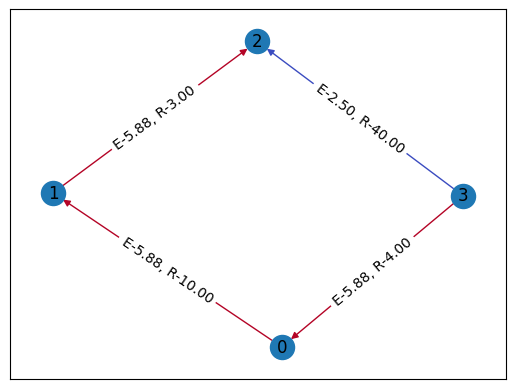

In [6]:
G, _ = rd_graph_from_file_nx('./graph/test')
params = potential_params(3, 2, 100)
V = find_potentials_nx(G, params)
plot_graph(G, V)

In [7]:
def ren(n, r_low=1, r_max=10):
    p = min(1.0, (np.log(n) + 5) / n)
    
    while True:
        graph = nx.Graph()
        graph.add_nodes_from(range(n))
        
        for i in range(n):
            for j in range(i+1, n):
                if np.random.random() < p:
                    r = np.random.randint(r_low, r_max)
                    graph.add_edge(i, j, R=r)
        
        if nx.is_connected(graph):
            return graph

In [8]:
def cubic(n, r_low=1, r_max=10):
    g = nx.Graph()
    
    for i in range(n):
        g.add_edge(i, (i+n-1)%n, R=np.random.randint(r_low, r_max))
        g.add_edge(i, (i+1)%n, R=np.random.randint(r_low, r_max))
        g.add_edge(i, (i+n//2)%n, R=np.random.randint(r_low, r_max))
    
    return g

In [9]:
def bridged(n, r_low=1, r_max=10):
    split = np.random.randint(5, n-5)

    g1 = ren(split, r_low, r_max)
    g2 = ren(n-split, r_low, r_max)
    
    g = nx.disjoint_union(g1, g2)
    
    nodes_G1 = list(g1.nodes())
    nodes_G2 = list(g2.nodes())
    
    offset = len(g1)
    
    u = np.random.choice(nodes_G1)
    v = np.random.choice(nodes_G2) + offset
    
    g.add_edge(u, v, R=np.random.randint(r_low, r_max))
    
    return g

In [10]:
def grid(n, m=10, r_low=1, r_max=10):
    G = nx.Graph()
    
    for i in range(n):
        for j in range(m):
            current_node = i * m + j
            
            if j < m - 1:
                right_node = i * m + (j + 1)
                G.add_edge(current_node, right_node, R=np.random.randint(r_low, r_max))
            
            if i < n - 1:
                bottom_node = (i + 1) * m + j
                G.add_edge(current_node, bottom_node, R=np.random.randint(r_low, r_max))
    
    return G

In [11]:
def small_world(n, k=3, p=0.2, r_low=1, r_max=10):
    g = nx.Graph()
    
    for i in range(n):
        g.add_edge(i, (i+1)%n, R=np.random.randint(r_low, r_max))
        g.add_edge(i, (i-1)%n, R=np.random.randint(r_low, r_max))
        for j in range(2, k+1):
            g.add_edge(i, (i+j)%n, R=np.random.randint(r_low, r_max))
            g.add_edge(i, (i-j)%n, R=np.random.randint(r_low, r_max))
    
    for u, v in list(g.edges()):
        if np.random.random() < (1 - p):
            continue
    
        r_val = g[u][v]['R']
        
        new_node = np.random.randint(0, n)
        while new_node == u or g.has_edge(u, new_node):
            new_node = np.random.randint(0, n)
    
        g.remove_edge(u, v)
        g.add_edge(u, new_node, R=r_val)
    
        if not nx.is_connected(g):
            g.remove_edge(u, new_node)
            g.add_edge(u, v, R=r_val)
            
    return g

In [12]:
def check_kirchhoff_fixed(g, s, t, voltage, total_input_current):
    n = g.number_of_nodes()
    node_balance = [0.0] * n
    
    node_balance[s] = total_input_current
    
    for u, v in g.edges():
        r = g[u][v]['R']
        current = (voltage[u] - voltage[v]) / r
        
        node_balance[u] -= current
        node_balance[v] += current
        
    is_correct = True
    for i in range(n):
        if i == s or i == t:
            continue
        if abs(node_balance[i]) > 1e-7:
            print(f"Błąd bilansu w węźle {i}: {node_balance[i]}")
            is_correct = False
            
    return is_correct

In [16]:
counts = [15, 30, 50, 70, 90, 100, 120, 140, 150, 170, 200]
functions = [ren, cubic, bridged, grid, small_world]
passed = []

for func in functions:
    print(f"Testy dla grafu typu \033[91m{func.__name__}\033[0m:")
    for n in counts:
        G = func(n)
        params = potential_params(3, 2, 100)
        #V = find_potentials_nx(G, params)
        V = find_potentials_kirchhoff(G, params)
        #plt.figure(figsize=(15, 10))
        #plot_graph(G, V)
        #plt.show()
        if check_kirchhoff_fixed(G,3, 2, V, V[-1]):
            print(f"\t - {n} wierzchołków -> \033[92m SUKCES \033[0m")
        else:
            print(f"\t - {n} wierzchołków -> \033[91m PORAŻKA \033[0m")

Testy dla grafu typu ren:
	 - 15 wierzchołków ->  SUKCES 
	 - 30 wierzchołków ->  SUKCES 
	 - 50 wierzchołków ->  SUKCES 
	 - 70 wierzchołków ->  SUKCES 
	 - 90 wierzchołków ->  SUKCES 
	 - 100 wierzchołków ->  SUKCES 
	 - 120 wierzchołków ->  SUKCES 
	 - 140 wierzchołków ->  SUKCES 
	 - 150 wierzchołków ->  SUKCES 
	 - 170 wierzchołków ->  SUKCES 
	 - 200 wierzchołków ->  SUKCES 
Testy dla grafu typu cubic:
	 - 15 wierzchołków ->  SUKCES 
	 - 30 wierzchołków ->  SUKCES 
	 - 50 wierzchołków ->  SUKCES 
	 - 70 wierzchołków ->  SUKCES 
	 - 90 wierzchołków ->  SUKCES 
	 - 100 wierzchołków ->  SUKCES 
	 - 120 wierzchołków ->  SUKCES 
	 - 140 wierzchołków ->  SUKCES 
	 - 150 wierzchołków ->  SUKCES 
	 - 170 wierzchołków ->  SUKCES 
	 - 200 wierzchołków ->  SUKCES 
Testy dla grafu typu bridged:
	 - 15 wierzchołków ->  SUKCES 
	 - 30 wierzchołków ->  SUKCES 
	 - 50 wierzchołków ->  SUKCES 
	 - 70 wierzchołków ->  SUKCES 
	 - 90 wierzchołków ->  SUKCES 
	 - 100 wierzchołków ->  SUKCES 
	 - 120